In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib widget

In [2]:
import sys
sys.path.append('../st_validate')
import periodic_kmeans
import apsym_kmeans
import sta
import utils
import numpy as np
from scipy.stats import vonmises, vonmises_fisher
import matplotlib.pyplot as plt

In [3]:
def bimodal_vonmises(mean1, mean2, kappa, size=500):
    m1 = mean1 + np.pi/2
    m2 = mean2 + np.pi/2
    angles = vonmises(loc=m1, kappa=kappa).rvs(size//2) # range: [-pi, pi]
    angles_ = vonmises(loc=m2, kappa=kappa).rvs(size//2 + size%2)
    angles = np.concatenate((angles, angles_))
    angles = np.where(angles < 0, angles + np.pi, angles) - np.pi/2 # range [-pi/2, pi/2]

    return angles

def bimodal_vonmises_fisher(mean1, mean2, kappa, size=500):
    data1 = vonmises_fisher(mean1, kappa=kappa).rvs(size//4)
    data1_ = vonmises_fisher(-mean1, kappa=kappa).rvs(size//4 + size%4)
    data2 = vonmises_fisher(mean2, kappa=kappa).rvs(size//4)
    data2_ = vonmises_fisher(-mean2, kappa=kappa).rvs(size//4 + size%4)
    data = np.concatenate((data1, data1_, data2, data2_))

    return data

def plot_hist_and_means(angles, means, nbins=100):

    fig = plt.figure()
    ax1 = plt.subplot(121)
    ax1.hist(angles, bins=nbins)
    colors = 'rgb'
    for i in range(len(means)):
        ax1.axvline(means[i], color=colors[i])
        n_bins = 100
    t = np.arange(nbins+1)*(2*np.pi/nbins) - np.pi
    angles_ = np.where(angles < 0, angles + np.pi, angles - np.pi)
    angles_sym = np.concatenate((angles, angles_), axis=0) # range [-pi, pi]
    x, _ = np.histogram(angles_sym, t)

    # smooth the histogram by exponential decay of the frequency domain.
    xf = np.fft.rfft(x)
    n = np.arange(len(xf))
    xf = xf * np.exp(-0.1*n)
    xfinv = np.fft.irfft(xf,n_bins+1)
    xfinv = xfinv / np.sum(xfinv)

    # ax_polar = fig.add_axes([0.,0.,1.,1.], projection="polar")
    ax2 = plt.subplot(122, projection="polar")
    ax2.plot(t, xfinv, linewidth=3.0)
    ax2.set_theta_offset(-np.pi/2)
    ax2.set_yticklabels([])
    ax_mean = fig.add_axes(ax2.get_position())
    ax_mean.patch.set_alpha(0)
    ax_mean.set_axis_off()
    for i in range(len(means)):
        color = np.abs(np.array([[np.sin(means[i]), 0.0, np.cos(means[i])]]))
        m = [np.sin(means[i]), np.cos(means[i])]
        ax_mean.quiver(0, 0, m[0], -m[1], scale_units='width', scale=3, width=0.02, color=color)
        ax_mean.quiver(0, 0, -m[0], m[1], scale_units='width', scale=3, width=0.02, color=color)

    plt.show()



# 2D tests

## Test periodic mean

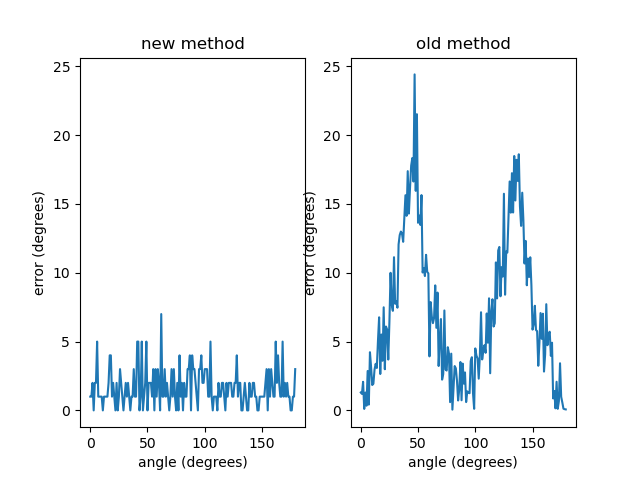

In [4]:
t = np.arange(0,np.pi,np.pi/180)

error_ = []
error = []
for i,mean in enumerate(t):
    angles = vonmises(loc=mean, kappa=3.0).rvs(500) # range: [-pi, pi]
    angles = np.where(angles < 0, angles + np.pi, angles) # range [0, pi]

    mu_ = periodic_kmeans.periodic_mean_(angles, period=np.pi)
    mu = periodic_kmeans.periodic_mean(angles, t, period=np.pi)

    err_ = periodic_kmeans.distance(np.array([mu_]), np.array([mean]), period=np.pi)[0,0]
    err = periodic_kmeans.distance(np.array([mu]), np.array([mean]), period=np.pi)[0,0]
    error_.append(err_)
    error.append(err)

error_ = np.array(error_)
error = np.array(error)
plt.figure()

ax1 = plt.subplot(121)
ax1.plot(t*180/np.pi, error*180/np.pi)
ax1.set_title('new method')
ax1.set_xlabel("angle (degrees)")
ax1.set_ylabel("error (degrees)")

ax2 = plt.subplot(122, sharey=ax1)
ax2.plot(t*180/np.pi, error_*180/np.pi)
ax2.set_title('old method')
ax2.set_xlabel("angle (degrees)")
ax2.set_ylabel("error (degrees)")

plt.show()

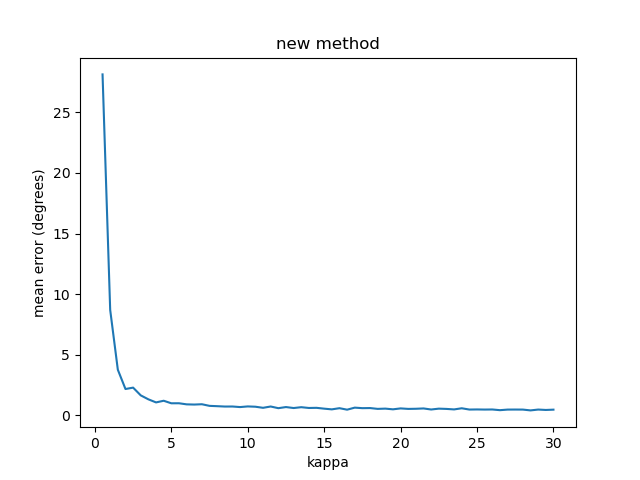

In [5]:
kappas = np.arange(0.5, 30.5, step=0.5,)
error = np.zeros((len(kappas), 100))
means = np.arange(0,180, 100/180) * np.pi/180
t = np.arange(0,180) * np.pi/180
for i,k in enumerate(kappas):
    for j in range(100):
        mean = means[j]
        angles = vonmises(loc=mean, kappa=k).rvs(500) # range: [-pi, pi]
        angles = np.where(angles < 0, angles + np.pi, angles) # range [0, pi]

        mu = periodic_kmeans.periodic_mean(angles, t, period=np.pi)

        err = periodic_kmeans.distance(np.array([mu]), np.array([mean]), period=np.pi) * 180/np.pi

        error[i,j] = err.item()

error = error.mean(axis=1)

plt.figure()

ax1 = plt.subplot(111)
ax1.plot(kappas, error)
ax1.set_title('new method')
ax1.set_xlabel("kappa")
ax1.set_ylabel("mean error (degrees)")


plt.show()

## Test periodic k-means

0.49999999999999434


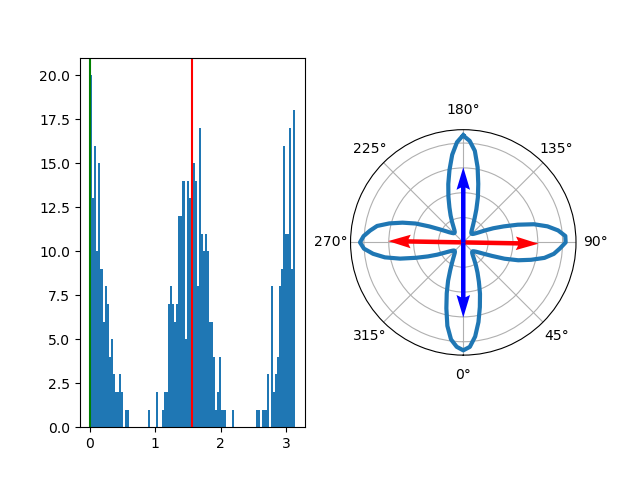

In [6]:
# angles = np.random.randn(200) * np.pi/2
mean1 = np.array([0.0])
mean2 = np.array([np.pi/2])

angles = bimodal_vonmises(mean1, mean2, kappa=20.0)
angles = np.where(angles < 0, angles + np.pi, angles)
mu = periodic_kmeans.periodic_kmeans(angles, k=2, period=np.pi)
# err = periodic_kmeans.distance(mu, np.array([mean1, mean2]), period=np.pi)
err = periodic_kmeans.distance(mu, np.concatenate((mean1, mean2)), period=np.pi)
err = periodic_kmeans.multiple_exclusive_distances(err)
err = np.mean(err)
print(err*180/np.pi)
plot_hist_and_means(angles, mu)


Text(0, 0.5, 'error (degrees)')

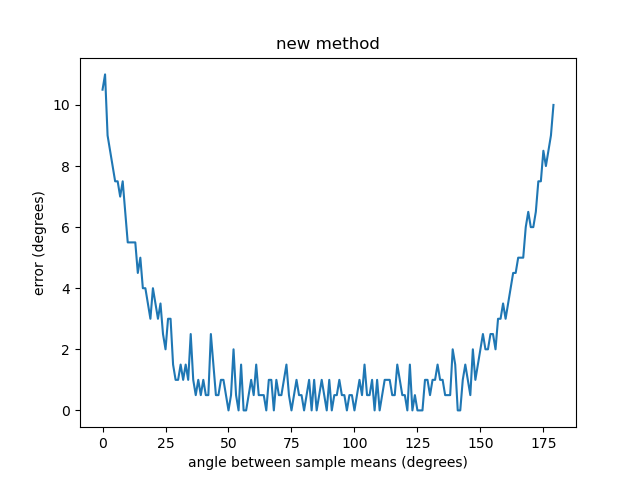

In [7]:
kappa=20.0
mean1 = np.array([0.0])
t = np.arange(180)*np.pi/180
error = []
for i in range(180):
    mean2 = np.array([t[i]])
    data = bimodal_vonmises(mean1, mean2, kappa, size=500)
    data = np.where(data < 0, data + np.pi, data) # range [0, pi]

    mu = periodic_kmeans.periodic_kmeans(data, k=2, period=np.pi, nstarts=10)
    err = periodic_kmeans.distance(mu, np.concatenate((mean1, mean2)), period=np.pi)
    err = periodic_kmeans.multiple_exclusive_distances(err)
    err = np.mean(err)
    error.append(err)

error = np.array(error)

plt.figure()

ax1 = plt.subplot(111)
ax1.plot(t*180/np.pi, error*180/np.pi)
ax1.set_title('new method')
ax1.set_xlabel("angle between sample means (degrees)")
ax1.set_ylabel("error (degrees)")

## Test 3D k-means

## Error as a function of kappa (variance)

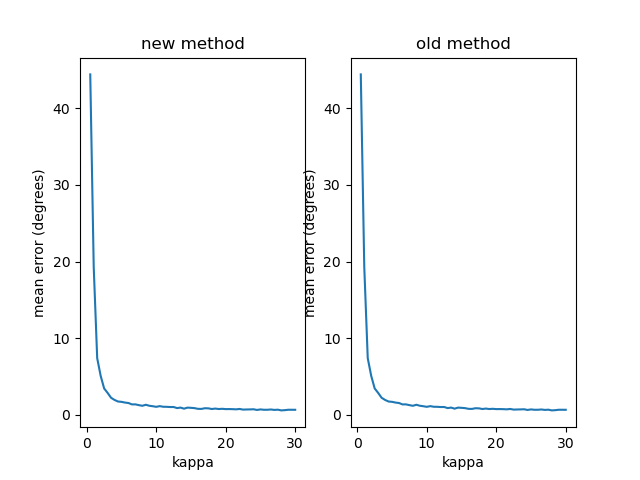

In [8]:
kappas = np.arange(0.5, 30.5, step=0.5,)
error = np.zeros((len(kappas), 100))
error_ = np.zeros((len(kappas), 100))
for i,k in enumerate(kappas):
    for j in range(100):
        mean = np.random.randn(3)
        mean = mean / np.linalg.norm(mean)
        data = vonmises_fisher(mean, kappa=k).rvs(500)

        mu = periodic_kmeans.apsym_kmeans(data, k=1, nstarts=1)

        skm = apsym_kmeans.APSymKMeans(n_clusters=1, verbose=False, random_state=0, n_init=1)
        skm.fit(data)
        mu_ = skm.cluster_centers_

        err = periodic_kmeans.distance_3d(mu, mean) * 180/np.pi
        err_ = periodic_kmeans.distance_3d(mu_, mean) * 180/np.pi

        error[i,j] = err.item()
        error_[i,j] = err.item()

error = error.mean(axis=1)
error_ = error_.mean(axis=1)

plt.figure()

ax1 = plt.subplot(121)
ax1.plot(kappas, error)
ax1.set_title('new method')
ax1.set_xlabel("kappa")
ax1.set_ylabel("mean error (degrees)")

ax2 = plt.subplot(122, sharey=ax1)
ax2.plot(kappas,error_)
ax2.set_title('old method')
ax2.set_xlabel("kappa")
ax2.set_ylabel("mean error (degrees)")

plt.show()



## Error as a function of angle between means

Text(0, 0.5, 'error (degrees)')

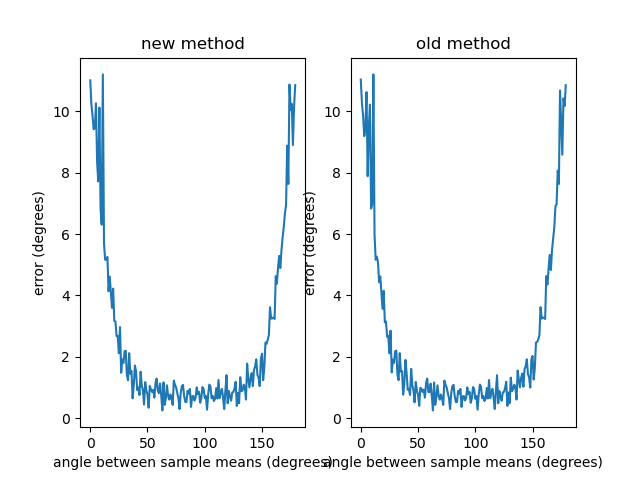

In [9]:
kappa=20.0
mean1 = np.array([0.0, 0.0])
mean1 = utils.sph_to_cart(mean1)
t = np.arange(180)*np.pi/180
error = []
error_ = []
for i in range(180):
    mean2 = np.array([t[i], 0.0])
    mean2 = utils.sph_to_cart(mean2)
    data = bimodal_vonmises_fisher(mean1, mean2, kappa, size=800)

    mu = periodic_kmeans.apsym_kmeans(data, k=2, nstarts=1)
    err = periodic_kmeans.distance_3d(mu, np.array([mean1, mean2]))
    err = periodic_kmeans.multiple_exclusive_distances(err)
    err = np.mean(err)
    error.append(err)

    skm = apsym_kmeans.APSymKMeans(n_clusters=2, verbose=False, random_state=0, n_init=1)
    skm.fit(data)
    mu_ = skm.cluster_centers_
    err_ = periodic_kmeans.distance_3d(mu_, np.array([mean1, mean2]))
    err_ = periodic_kmeans.multiple_exclusive_distances(err_)
    err_ = np.mean(err_)
    error_.append(err_)

error = np.array(error)
error_ = np.array(error_)

plt.figure()

ax1 = plt.subplot(121)
ax1.plot(t*180/np.pi, error*180/np.pi)
ax1.set_title('new method')
ax1.set_xlabel("angle between sample means (degrees)")
ax1.set_ylabel("error (degrees)")

ax2 = plt.subplot(122, sharey=ax1)
ax2.plot(t*180/np.pi, error_*180/np.pi)
ax2.set_title('old method')
ax2.set_xlabel("angle between sample means (degrees)")
ax2.set_ylabel("error (degrees)")
    